In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Define the path to our data file
path_1 = "mexico-city-real-estate-1.csv"
print(f'Load data from: "{path_1}"')
asf1=pd.read_csv(path_1)
asf1.head()

Load data from: "mexico-city-real-estate-1.csv"


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,NaN,54.0,NaN,101851.851900,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/o3zb...
1,sell,house,|Iztapalapa|Distrito Federal|México|,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,NaN,80.0,NaN,18900.000000,NaN,NaN,NaN,http://iztapalapa.properati.com.mx/q7t0_venta_...
2,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,NaN,100.0,NaN,9266.670000,NaN,NaN,NaN,http://tlalpan.properati.com.mx/qbi4_venta_dep...
3,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,NaN,135.0,NaN,47481.481480,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/opeq...
4,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1902642,-86.8198375",875000.0,USD,16457437.50,875000.00,0.0,263.0,NaN,3326.996198,NaN,NaN,NaN,http://cancun.properati.com.mx/hg4t_venta_depa...


In [3]:
path_2 = "mexico-city-real-estate-2.csv"
print(f'Load data from: "{path_2}"')
asf2=pd.read_csv(path_2)
asf2.head()


Load data from: "mexico-city-real-estate-2.csv"


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.516777,-99.160149",1200000.0,MXN,1189144.46,63223.78,88.0,88.0,718.452046,13636.36364,NaN,NaN,NaN,http://gustavo-a-madero.properati.com.mx/r644_...
1,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.466724,-99.131614",480000.0,MXN,475657.74,25289.51,NaN,48.0,NaN,10000.00000,NaN,NaN,NaN,http://vallejo.properati.com.mx/mz4c_venta_dep...
2,sell,apartment,|Álvaro Obregón|Distrito Federal|México|,"19.33228,-99.243934",4559261.0,MXN,4518016.68,240211.43,NaN,126.0,NaN,36184.61111,NaN,NaN,NaN,http://alvaro-obregon.properati.com.mx/jh8j_ve...
3,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1105772788,-86.8537859927",3808088.0,MXN,3774533.79,200682.34,0.0,171.0,NaN,22269.52047,NaN,NaN,NaN,http://cancun.properati.com.mx/qus8_venta_depa...
4,sell,apartment,|Benito Juárez|Distrito Federal|México|,"19.39365,-99.14769",1730000.0,MXN,1714349.82,91147.61,NaN,100.0,NaN,17300.00000,NaN,NaN,NaN,http://benito-juarez.properati.com.mx/q5my_ven...


In [4]:
column_match= set(asf1)==set(asf2)
if column_match:
    print('The features of the two dataset are same')
    real_estate_df= pd.concat([asf1,asf2], ignore_index=True)
    print('Concatenation Succesful')
else:
    raise Exception('The features of two dataset are not same')

The features of the two dataset are same
Concatenation Succesful


In [5]:
real_estate_df.shape

(9256, 16)

In [6]:
real_estate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9256 entries, 0 to 9255
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   9256 non-null   str    
 1   property_type               9256 non-null   str    
 2   place_with_parent_names     9256 non-null   str    
 3   lat-lon                     8289 non-null   str    
 4   price                       9090 non-null   float64
 5   currency                    9090 non-null   str    
 6   price_aprox_local_currency  9090 non-null   float64
 7   price_aprox_usd             9090 non-null   float64
 8   surface_total_in_m2         3449 non-null   float64
 9   surface_covered_in_m2       8881 non-null   float64
 10  price_usd_per_m2            2410 non-null   float64
 11  price_per_m2                8511 non-null   float64
 12  floor                       613 non-null    float64
 13  rooms                       253 non-null    

In [7]:
real_estate_df.dtypes

operation                         str
property_type                     str
place_with_parent_names           str
lat-lon                           str
price                         float64
currency                          str
price_aprox_local_currency    float64
price_aprox_usd               float64
surface_total_in_m2           float64
surface_covered_in_m2         float64
price_usd_per_m2              float64
price_per_m2                  float64
floor                         float64
rooms                         float64
expenses                      float64
properati_url                     str
dtype: object

In [8]:
real_estate_df.isnull().sum()

operation                        0
property_type                    0
place_with_parent_names          0
lat-lon                        967
price                          166
currency                       166
price_aprox_local_currency     166
price_aprox_usd                166
surface_total_in_m2           5807
surface_covered_in_m2          375
price_usd_per_m2              6846
price_per_m2                   745
floor                         8643
rooms                         9003
expenses                      9250
properati_url                    0
dtype: int64

In [9]:
real_estate_df = (real_estate_df.drop(columns=['operation','currency','price','price_aprox_local_currency','price_usd_per_m2','floor','rooms','expenses','properati_url','price_per_m2' ])
                .dropna()
                  )


In [10]:
real_estate_df.place_with_parent_names= real_estate_df.place_with_parent_names.astype('string')
real_estate_df['lat-lon'] = real_estate_df['lat-lon'].astype('string')

real_estate_df=((real_estate_df.assign(state=lambda x: x["place_with_parent_names"].str.split("|", expand=True)[2],
                 lat=lambda x:x['lat-lon'].str.split(',').str[0],
                 lon=lambda x:x['lat-lon'].str.split(',').str[1])
                 )
        .drop(columns=['place_with_parent_names','lat-lon']))

In [11]:

real_estate_df 


,property_type,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,state,lat,lon
4,apartment,875000.00,0.0,263.0,Quintana Roo,21.1902642,-86.8198375
12,apartment,300000.00,1500.0,160.0,Quintana Roo,20.4987828982,-87.2228193283
13,apartment,172446.86,0.0,83.0,Distrito Federal,19.3794059,-99.1591446
15,apartment,115000.00,49.0,49.0,Quintana Roo,21.0511211635,-86.7828512192
20,apartment,70880.12,56.0,56.0,Distrito Federal,19.4024128,-99.0953907
...,...,...,...,...,...,...,...
9229,house,299000.00,0.0,234.0,Quintana Roo,20.2268999,-87.4336011
9233,apartment,53967.66,0.0,63.0,Distrito Federal,19.2990233,-99.0436467
9238,apartment,83264.38,0.0,54.0,Distrito Federal,19.458118,-99.125557
9241,house,2975000.00,762.0,762.0,Distrito Federal,19.420166,-99.220367


In [12]:
real_estate_df.to_csv("mexico-real-estate-combined-clean.csv", index=False)

Text(0, 0.5, 'Frequency')

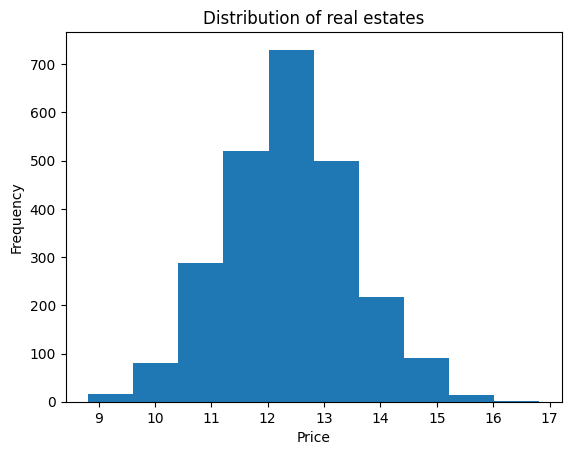

In [13]:
fig,ax=plt.subplots()
ax.hist(np.log1p(real_estate_df['price_aprox_usd'])) # We take log of price to better visualize the distribution we take log1p because log can't handle 0 but log1p(x) can because it handles 1+x
ax.set_title('Distribution of real estates')
ax.set_xlabel('Price')
ax.set_ylabel('Frequency')

Text(0.5, 0, 'Total Surface Area')

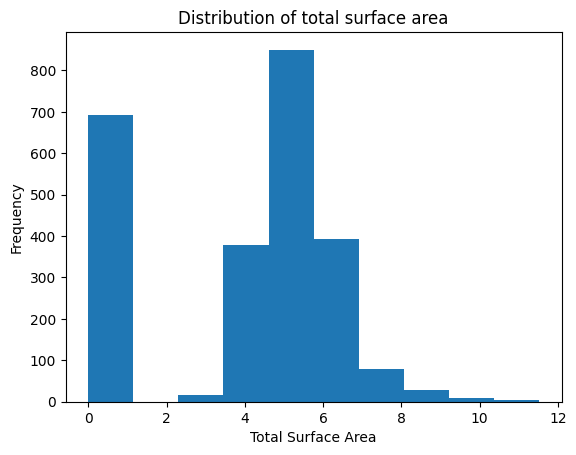

In [14]:
fig,ax=plt.subplots()
ax.hist(np.log1p(real_estate_df['surface_total_in_m2']))
ax.set_title('Distribution of total surface area')
ax.set_ylabel('Frequency')
ax.set_xlabel('Total Surface Area')

C:\Users\Acer\AppData\Local\Temp\ipykernel_14300\40063131.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_type,labels=property_types)


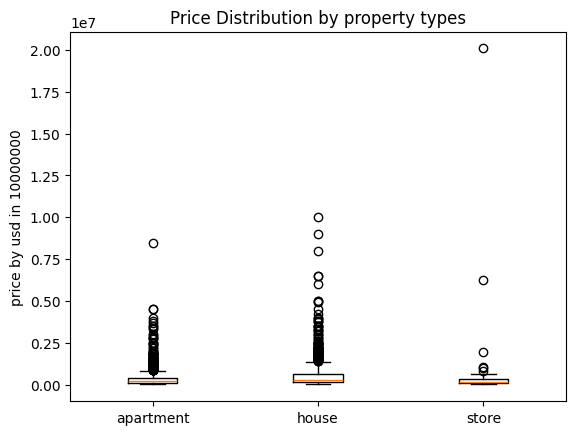

In [15]:
property_types=real_estate_df['property_type'].unique()
data_by_type=[real_estate_df[real_estate_df['property_type']== type]["price_aprox_usd"] for type in property_types]
fig,ax=plt.subplots()
ax.boxplot(data_by_type,labels=property_types)
ax.set_title('Price Distribution by property types')
ax.set_ylabel('price by usd in 10000000')
plt.show()

Text(0.5, 0, 'Price of usd in 10000000')

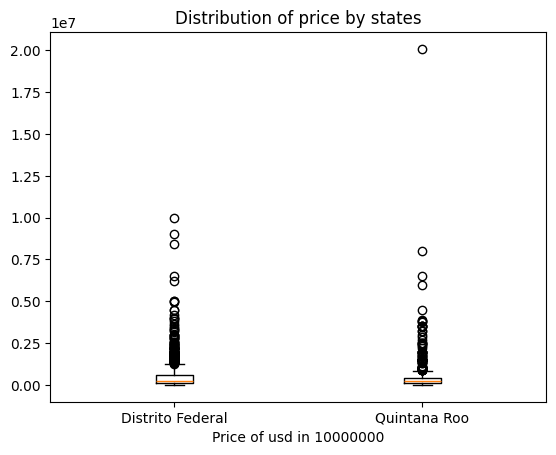

In [16]:
topstates=(real_estate_df['state']
    .value_counts()
    .head(2)
    .index.tolist())

data_state=[real_estate_df[real_estate_df['state']==state]["price_aprox_usd"] for state in topstates]
fig, ax= plt.subplots()
ax.boxplot(data_state,tick_labels=topstates)
ax.set_title("Distribution of price by states")
ax.set_xlabel("Price of usd in 10000000")

In [17]:
lower_limit=0.05
upper_limit=0.95
df= real_estate_df
df_clean=(
    df[
        (df["price_aprox_usd"]>df["price_aprox_usd"].quantile(lower_limit)) &
        (df["price_aprox_usd"]<df["price_aprox_usd"].quantile(upper_limit)) &
        (df["surface_total_in_m2"]>df["surface_total_in_m2"].quantile(lower_limit)) &
        (df["surface_total_in_m2"]<df["surface_total_in_m2"].quantile(upper_limit)) 
    ]
    )

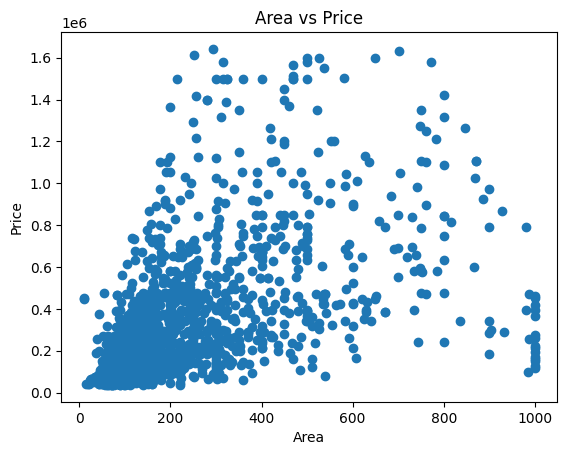

In [18]:
fig, ax= plt.subplots()
ax.scatter(df_clean['surface_total_in_m2'],df_clean['price_aprox_usd'])
ax.set_title('Area vs Price')
ax.set_xlabel('Area')
ax.set_ylabel('Price')
plt.show()

<Axes: xlabel='surface_total_in_m2', ylabel='price_aprox_usd'>

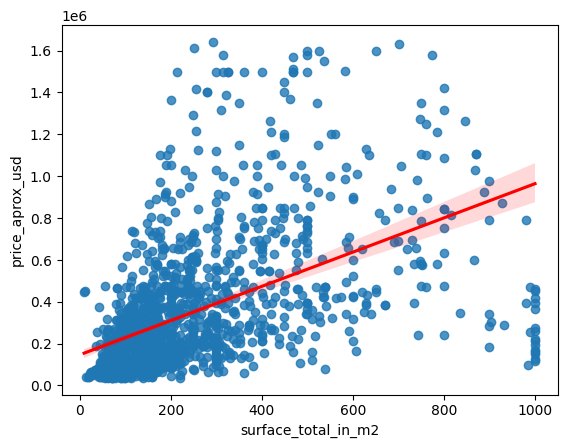

In [19]:
import seaborn as sns
fig,ax= plt.subplots()
sns.regplot(
    data=df_clean,
    x="surface_total_in_m2",
    y='price_aprox_usd',
    line_kws={'color':'red'},
)


In [20]:
mean_state=df.groupby('state')['price_aprox_usd'].mean().sort_values()

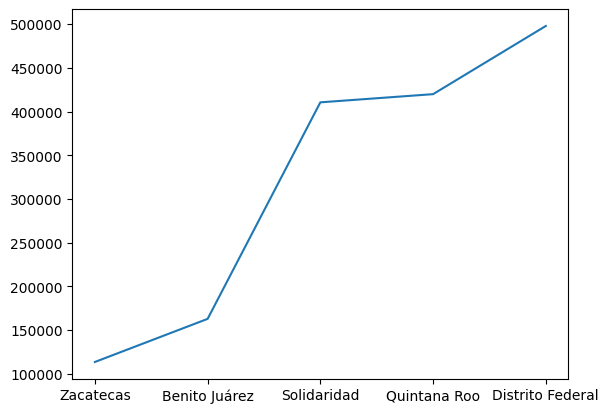

In [21]:
fig,ax=plt.subplots()
ax.plot(mean_state)

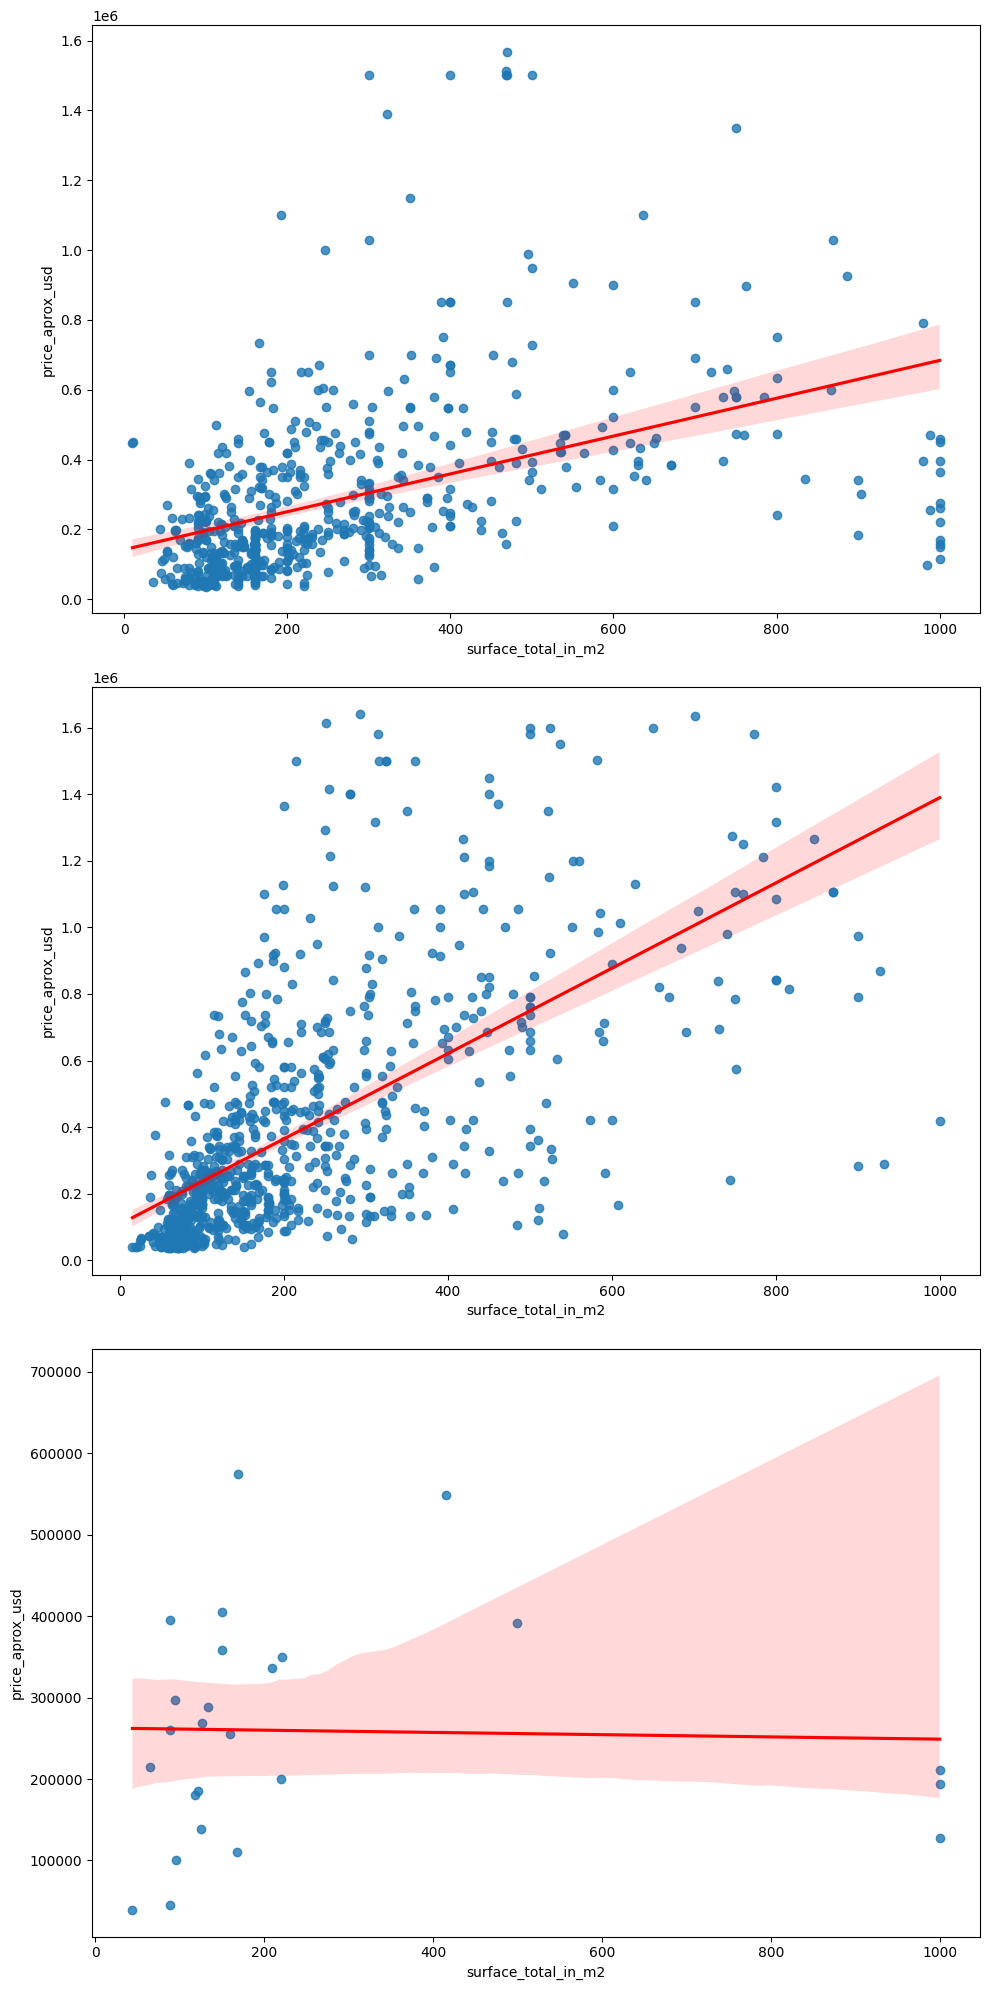

In [22]:
fig, axes= plt.subplots(3,1,figsize=(10,20))
df_states=df_clean[df_clean['state'].isin(topstates)]
states=df['state'].unique()
for ax, state in zip(axes,states):
    sample=df_clean[df_clean['state']==state]
    sns.regplot(
        data=sample,
        x="surface_total_in_m2",
        y='price_aprox_usd',
        line_kws={'color':'red'},
        ax=ax
        )
plt.tight_layout()
plt.show()

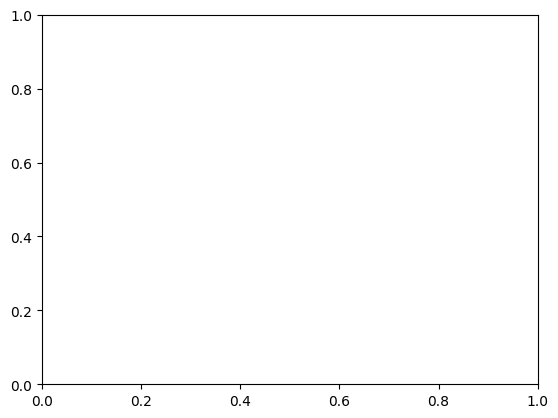

In [23]:
fig,ax= plt.subplots()


In [24]:
corr_price_area=real_estate_df["surface_covered_in_m2"].corr(real_estate_df['price_aprox_usd'])
corr_price_area
print(f'The correlation between area and price of property is {corr_price_area}')

The correlation between area and price of property is 0.3920055927255342


In [25]:
corr_matrix = (
    real_estate_df
    .select_dtypes("number") # to select the numeric data only
    .corr()
)

corr_matrix

,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2
price_aprox_usd,1.000000,0.073562,0.392006
surface_total_in_m2,0.073562,1.000000,0.054761
surface_covered_in_m2,0.392006,0.054761,1.000000


Text(0.5, 1.0, 'Correlation Matrix for numerical features of Real Estate Data')

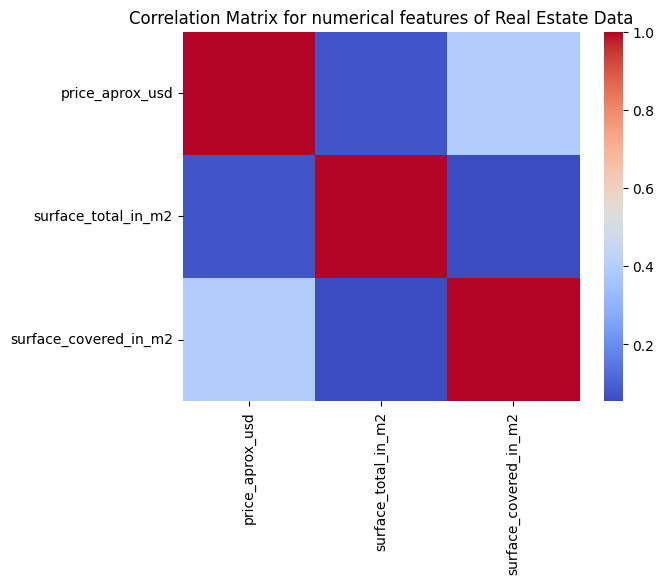

In [26]:
fig,ax=plt.subplots()
sns.heatmap(corr_matrix,cmap='coolwarm',ax=ax)
ax.set_title('Correlation Matrix for numerical features of Real Estate Data')

In [27]:
(real_estate_df.groupby("state")[['surface_covered_in_m2','price_aprox_usd']]
 .corr()
 .iloc[:,1]
 .xs('surface_covered_in_m2',level=1))


state
Benito Juárez      -0.707185
Distrito Federal    0.594166
Quintana Roo        0.254076
Solidaridad         0.466269
Zacatecas          -0.384412
Name: price_aprox_usd, dtype: float64

In [28]:
(real_estate_df.groupby('property_type')[['surface_covered_in_m2','price_aprox_usd']]
 .corr()
 .iloc[:,1]
 .xs('surface_covered_in_m2',level=1)
)



property_type
apartment    0.168969
house        0.715827
store        0.705616
Name: price_aprox_usd, dtype: float64

In [29]:
data = (
    real_estate_df
    .assign(price_per_m2 = lambda x: x['price_aprox_usd'] / x['surface_covered_in_m2'])
)

data.head()
data.shape
data = data[
    (data["surface_covered_in_m2"] < 5000) &
    (data["price_per_m2"] < 20000)
]


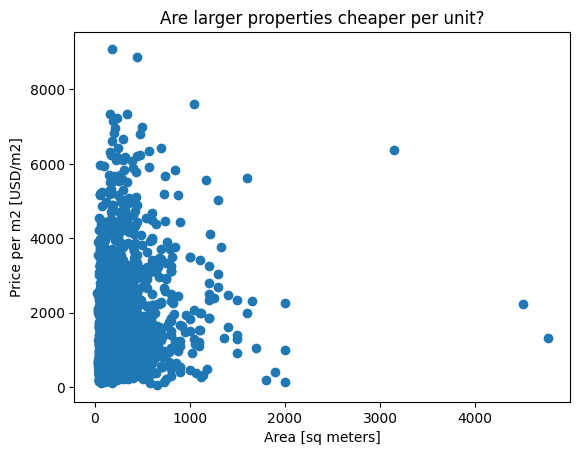

In [30]:
fig, ax = plt.subplots()

# Scatter plot
ax.scatter(x=data["surface_covered_in_m2"], y=data["price_per_m2"],)

ax.set_title("Are larger properties cheaper per unit?")
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price per m2 [USD/m2]")

plt.show()